In [1]:
# importar bibliotecas

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml





# DESAFIO 
Benchmark Comparativo: Implementar e contrastar o desempenho de 3 modelos preditivos distintos podendo mesclar entre:

==> algoritmos clássicos: SVM, Random Forest, KNN, Gradient Boosting

==> Redes Neurais Artificiais/MLP: TensorFlow/Keras


Estresse e Robustez (Testes de Generalização Extrema): 

==> Avaliar o comportamento dos modelos sob premissas fora da distribuição de treino 
(OOD - Out-of-Distribution) 

==> testar a capacidade de inferência com dígitos 
manuscritos digitalizados pelos próprios alunos. 



# Fase 1: Carregamento e Análise Exploratória de Imagens (EDA) 

● Importar o dataset MNIST via scikit-learn (fetch_openml('mnist_784')) ou via 
tensorflow.keras.datasets.mnist. 

● Exibir a dimensionalidade das matrizes (X e y) e comprovar a distribuição 
das classes (balanceamento de dígitos de 0 a 9). 

● Gerar uma grade visual  de no mínimo 2 x 5 com matplotlib, exibindo 
exemplos de imagens de cada dígito junto com seus respectivos rótulos 
originais. 

● Inserir célula de texto interpretando a estrutura dos dados: explicar o 
significado da escala de intensidade de pixels (0 a 255) e como imagens 
bidimensionais (28 x 28) são representadas vetorialmente (784 features). 

In [2]:
# importacao da base de dados Mnist

from sklearn.datasets import fetch_openml 
print("Baixando o dataset MNIST...") 
mnist = fetch_openml('mnist_784', version=1, 
as_frame=False, parser='auto') 
print("Finalizou o processo de baixar o dataset MNIST!") 

Baixando o dataset MNIST...
Finalizou o processo de baixar o dataset MNIST!


In [3]:
# Separando Entradas (X) e Rótulos (y)
X, y = mnist.data, mnist.target

In [4]:

X[10]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,  42, 118, 219, 166, 118, 118,   6,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0, 103, 242, 254, 254, 254, 254,
       254,  66,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,  18, 232, 25

In [5]:
# essas imagens sao representadas por vetor (linhas e colunas)
# visualizar quantos linha e colunas existem no dataset

X.shape

(70000, 784)

In [6]:
y

array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object)

In [7]:
# Como o target vem como string ('0', '1', ...), importante é converter para inteiros
y = y.astype(np.uint8)

In [8]:
# Exibir a dimensionalidade das matrizes (X e y) e comprovar a distribuição das classes (balanceamento de dígitos de 0 a 9).

print(f"Formato de X (amostras, pixels por imagem): {X.shape}") # (70000, 784)
print(f"Formato de y (rótulos): {y.shape}")                     # (70000,)
print(f"Classes únicas existentes: {np.unique(y)}")   # com esse comando visualiza unicas classes (sem repetição)

Formato de X (amostras, pixels por imagem): (70000, 784)
Formato de y (rótulos): (70000,)
Classes únicas existentes: [0 1 2 3 4 5 6 7 8 9]


# INTERPRETACAO:
 O que significa a escala de intensidade de pixels (0 a 255) e como imagens 
bidimensionais (28 x 28) são representadas vetorialmente (784 features):

1) A base MNIST é um dataset que contem 70.000 imagens (números/dígitos de 0 a 9 manuscritos) em escalas(tons) de cinza.
2) cada imagem tem a dimensão de 28 x 28 pixels (um quadrado de 28 x 28 pixels , X, y)
3) a tonalidade do cinza vai de '0' a '255', onde '0' é fundo preto (ou branco) e o '255' é o traço mais forte da caneta
4) modelos classicos de ML (svm, knn, r.forest ou regressao logistica) nao entendem matrizes de imagem 2d, por isso, 
    cada imagem de 28x28 é 'achatada' em uma linha com 784 colunas (o '784' vem da multiplicacao de 28x28)
    seria 784 variaveis numericas, ou seja, passou de imagem para número.
    a imagem se torna um 'vetor' (array de numpy)  [0,   0,   0,   0,   0,   0,  42, 118, 219, 166, 118, 118,   6]

resumo: as imagens sao convertidas em numeros, onde neste dataset sao 70.000 imagens (cada linha e 784 colunas representam uma imagem)
o data set teria 70.000 x 784 = 54.880.000 caracteres.




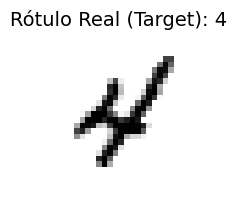

In [10]:
# escolher uma imagem aleatória (digito_exemplo)
digito_exemplo = X[9]
digito_imagem = digito_exemplo.reshape(28, 28)

plt.figure(figsize=(2, 5))
plt.imshow(digito_imagem, cmap='binary') # cmap='binary' mostra preto no branco
plt.title(f"Rótulo Real (Target): {y[2]}", fontsize=14)
plt.axis('off') # Oculta os eixos cartesianos
plt.show()

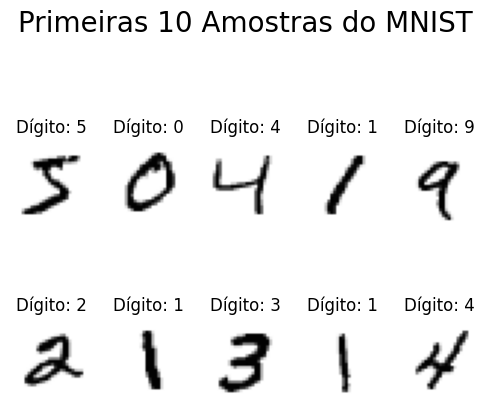

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(5, 5))

for i, ax in enumerate(axes.flat):
    # Remodela a i-ésima imagem para 28x28
    ax.imshow(X[i].reshape(28, 28), cmap='binary')
    ax.set_title(f"Dígito: {y[i]}")
    ax.axis('off')

plt.suptitle("Primeiras 10 Amostras do MNIST", fontsize=20)
plt.tight_layout()
plt.show()

# Fase 2: Pipeline de Pré-processamento e Divisão dos Dados  

● Divisão Estratificada: Dividir a base em Treino, Validação e Teste (ex: 70% 
treino, 10% validação e 20% teste ou 80% treino/validação e 20% teste), 
garantindo estratificação por classe (stratify=y). 

● Normalização / Escalonamento: Aplicar o redimensionamento dos pixels 
para escala [0.0, 1.0]. (dividindo por 255.0 ou via MinMaxScaler/StandardScaler)
                                                      
● Justificar textualmente a importância da normalização para a convergência 
de modelos lineares e distâncias métricas. 

In [ ]:
# Divisão Estratificada: Dividir a base em Treino, Validação e Teste 
# 70% treino, 10% validação e 20% teste //  80% treino/validação e 20% teste
# garantindo estratificação por classe (stratify=y). 

# 1. Divisão estratificada

from sklearn.model_selection import train_test_split

# Primeiro: 80% para treino + validação e 20% para teste
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Segundo: dentro dos 80%, separar 10% validação e 70% treino
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.125,
    random_state=42,
    stratify=y_train_val
)

# 2. Verificar o resultado do split

print("Treino 70%:", X_train.shape, y_train.shape)
print("Validação 10%:", X_val.shape, y_val.shape)
print("Teste 20%:", X_test.shape, y_test.shape)

Treino 70%: (49000, 784) (49000,)
Validação 10%: (7000, 784) (7000,)
Teste 20%: (14000, 784) (14000,)


In [ ]:
# verificar a distribuição:

import pandas as pd

print("Distribuição no treino:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())

print("\nDistribuição na validação:")
print(pd.Series(y_val).value_counts(normalize=True).sort_index())

print("\nDistribuição no teste:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index())

Distribuição no treino:
0    0.098612
1    0.112531
2    0.099857
3    0.102020
4    0.097490
5    0.090184
6    0.098224
7    0.104184
8    0.097490
9    0.099408
Name: proportion, dtype: float64

Distribuição na validação:
0    0.098571
1    0.112571
2    0.099857
3    0.102000
4    0.097429
5    0.090143
6    0.098286
7    0.104143
8    0.097571
9    0.099429
Name: proportion, dtype: float64

Distribuição no teste:
0    0.098643
1    0.112500
2    0.099857
3    0.102000
4    0.097500
5    0.090214
6    0.098214
7    0.104214
8    0.097500
9    0.099357
Name: proportion, dtype: float64


In [17]:
# Normalização / Escalonamento: Aplicar o redimensionamento dos pixels 
# para escala [0.0, 1.0]. (dividindo por 255.0 ou via MinMaxScaler/StandardScaler)

# 3. Normalização dos pixels
# transformar 0 --> 255 em 0.0 --> 1.0

X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

print("Menor valor:", X_train.min())
print("Maior valor:", X_train.max())



Menor valor: 0.0
Maior valor: 1.0


# Justificativa da normalização

As imagens do MNIST possuem pixels representados originalmente por valores entre 0 e 255. Neste projeto, os valores foram normalizados para o intervalo entre 0 e 1 por meio da divisão por 255.

A normalização reduz a escala numérica das características e contribui para um processo de treinamento mais estável. Essa transformação é especialmente importante para algoritmos sensíveis à escala das variáveis.

Em modelos que utilizam otimização baseada em gradiente, como redes neurais e alguns modelos lineares, características em escalas muito diferentes podem dificultar a convergência e tornar o processo de aprendizado menos eficiente.

Além disso, algoritmos baseados em distância, como o KNN, são diretamente influenciados pela escala das características. Como cada pixel representa uma característica, manter todos os pixels em uma escala uniforme evita que diferenças de escala prejudiquem o cálculo das distâncias.

Portanto, a normalização para [0.0, 1.0] torna os dados mais adequados para os algoritmos que serão utilizados nas etapas seguintes.

# Fase 3: Implementação e Treinamento dos 3 Modelos 
Deve-se obrigatoriamente escolher e treinar 3 modelos distintos, podendo optar 
por combinações de:  

● Modelos Clássicos: SVM (Support Vector Machines), Random Forest, KNN 
(K-Nearest Neighbors), XGBoost / Gradient Boosting, Regressão Logística 
Multinomial, etc  

● Redes Neurais: Perceptron Multicamadas (MLP via Scikit-Learn ou 
TensorFlow/Keras).  

● Cada modelo deve possuir ajuste justificado de ao menos 2 
hiperparâmetros (ex: n_estimators e max_depth na Random Forest;  

n_neighbors e weights no KNN; C e kernel no SVM; número de neurônios, 
taxa de aprendizado ou funções de ativação na Rede Neural)  

● Caso queiram usar outros modelos não citados acima, é permitido, desde 
que justificadas as escolhas.


# Modelos escolhidos

    ### SVM: modelo clássico baseado em margem.
    ### Random Forest: ensemble de árvores de decisão.
    ### MLP: rede neural multicamadas.

Modelo--------> Hiperparâmetros------------> Motivo   
SVM------------> C, kernel-----------------> Controla regularização e tipo de fronteira de decisão   
Random Forest--> n_estimators, max_depth--->Controla quantidade e complexidade das árvores  
MLP-----------> hidden_layer_sizes,   
----------------learning_rate_init---------->Controla arquitetura e velocidade de aprendizado  

# 1o. MODELO ==> SVC (Support Vector Machine) do Scikit-Learn:

Hiperparâmetro 1 — C

        C controla o quanto o modelo penaliza erros de classificação.

            C baixo → maior regularização.  
            C alto → tenta ajustar mais os dados de treinamento.  

        Exemplo inicial "C = 10"
  

Hiperparâmetro 2 — kernel

        O kernel determina como o SVM representa a relação entre as classes.


        Exemplo inicial kernel="rbf"

            O rbf é interessante para MNIST porque permite criar fronteiras de decisão não lineares.


In [ ]:
#importar SVC

from sklearn.svm import SVC

In [19]:
# criar o modelo

modelo_svm = SVC(
    C=10,
    kernel="rbf"
)

In [ ]:
# treinando o modelo

# não utilizado X_test nem y_test aqui para preservar a independência do conjunto de test

modelo_svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [21]:
# Medir o tempo de treinamento
# comparar custo computacional × desempenho (começar a registrar o tempo)

import time

inicio = time.time()

modelo_svm.fit(X_train, y_train)

tempo_svm = time.time() - inicio

print(f"Tempo de treinamento SVM: {tempo_svm:.2f} segundos")

Tempo de treinamento SVM: 173.54 segundos


In [31]:
# Validação do SVM

acuracia_svm_val = modelo_svm.score(X_val, y_val)

print(f"Acurácia SVM na validação: {acuracia_svm_val:.4f}")

Acurácia SVM na validação: 0.9814


# 2o. MODELO ==> Random Forest

Hiperparâmetro 1 — n_estimators

        Exemplo:  'n_estimators=150'  (Mais árvores geralmente aumentam a estabilidade do modelo, mas também aumentam  
                                     o custo computacional.)

Hiperparâmetro 2 — max_depth

        Exemplo: 'max_depth=20'  (Uma profundidade maior permite modelos mais complexos, mas aumenta o risco de overfitting  
                                e o custo computaciona)

In [23]:
# criar o Modelo

# random_state=42 é usado para permitir reprodutibilidade.
# n_jobs=-1 permite utilizar os processadores disponíveis para acelerar o treinamento.  

from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)



In [24]:
# treinamento

inicio = time.time()

modelo_rf.fit(X_train, y_train)

tempo_rf = time.time() - inicio

print(f"Tempo de treinamento Random Forest: {tempo_rf:.2f} segundos")


Tempo de treinamento Random Forest: 13.52 segundos


In [33]:
# validação

acuracia_rf_val = modelo_rf.score(X_val, y_val)

print(f"Acurácia Random Forest na validação: {acuracia_rf_val:.4f}")



Acurácia Random Forest na validação: 0.9659


# 3o. MODELO ==> MLP Classifier, do Scikit-Learn

Hiperparâmetro 1 — hidden_layer_sizes  (Esse parâmetro define a quantidade de neurônios nas camadas ocultas.)

        Exemplo:  hidden_layer_sizes=(128, 64)  
                    significa 784 entradas, 128 neuronios, 64 neuronios, 10 classes
                    *cada imagem possui 784 pixels, a entrada possui 784 caracteristivas

Hiperparâmetro 2 — learning_rate_init (Define a taxa inicial de aprendizado.)

        Exemplo: 'learning_rate_init=0.001'
                    (Uma taxa muito alta pode dificultar a convergência.
                    Uma taxa muito baixa pode tornar o treinamento muito lento.)



In [27]:
from sklearn.neural_network import MLPClassifier


# max_iter=20 limita o número de iterações para controlar o tempo de treinamento.
# random_state=42 garante reprodutibilidade.


modelo_mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    learning_rate_init=0.001,
    max_iter=20,
    random_state=42
)

In [28]:
# Treinar a MLP

inicio = time.time()

modelo_mlp.fit(X_train, y_train)

tempo_mlp = time.time() - inicio

print(f"Tempo de treinamento MLP: {tempo_mlp:.2f} segundos")

Tempo de treinamento MLP: 47.48 segundos


c:\Users\rafad\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [29]:
# Avaliar na validação

acuracia_mlp_val = modelo_mlp.score(X_val, y_val)

print(f"Acurácia MLP na validação: {acuracia_mlp_val:.4f}")

Acurácia MLP na validação: 0.9747


# Comparativo entre os 3 modelos

In [34]:
print("RESULTADOS NA VALIDAÇÃO")
print("-" * 40)

print(f"SVM           : {acuracia_svm_val:.4f}")
print(f"Random Forest : {acuracia_rf_val:.4f}")
print(f"MLP           : {acuracia_mlp_val:.4f}")

RESULTADOS NA VALIDAÇÃO
----------------------------------------
SVM           : 0.9814
Random Forest : 0.9659
MLP           : 0.9747


In [35]:
# tempos de execução

print("\nTEMPO DE TREINAMENTO")
print("-" * 40)

print(f"SVM           : {tempo_svm:.2f} segundos")
print(f"Random Forest : {tempo_rf:.2f} segundos")
print(f"MLP           : {tempo_mlp:.2f} segundos")


TEMPO DE TREINAMENTO
----------------------------------------
SVM           : 173.54 segundos
Random Forest : 16.07 segundos
MLP           : 47.48 segundos


In [36]:
# Criar uma tabela

resultados_modelos = pd.DataFrame({
    "Modelo": [
        "SVM",
        "Random Forest",
        "MLP"
    ],
    "Acuracia_Validacao": [
        acuracia_svm_val,
        acuracia_rf_val,
        acuracia_mlp_val
    ],
    "Tempo_Treinamento": [
        tempo_svm,
        tempo_rf,
        tempo_mlp
    ]
})

resultados_modelos

,Modelo,Acuracia_Validacao,Tempo_Treinamento
0,SVM,0.981429,173.542500
1,Random Forest,0.965857,16.074268
2,MLP,0.974714,47.481259


# Justificativa escolha dos modelos

Foram selecionados três modelos de características distintas: Support Vector Machine (SVM), Random Forest e Perceptron Multicamadas (MLP). A escolha permite comparar diferentes estratégias de classificação para o reconhecimento de dígitos manuscritos.

O SVM foi escolhido por sua capacidade de construir fronteiras de decisão eficientes em problemas de classificação e por permitir a utilização do kernel RBF para representar relações não lineares. Foram ajustados os hiperparâmetros C=10 e kernel='rbf'.

O Random Forest foi escolhido por utilizar um conjunto de árvores de decisão, proporcionando um modelo robusto e capaz de representar relações não lineares. Foram ajustados n_estimators=150, que define a quantidade de árvores, e max_depth=20, que controla a profundidade máxima das árvores.

O MLP foi escolhido para representar uma abordagem baseada em redes neurais artificiais. Sua arquitetura possui duas camadas ocultas com 128 e 64 neurônios. Foram ajustados hidden_layer_sizes=(128, 64) e learning_rate_init=0.001, relacionados respectivamente à arquitetura da rede e à taxa inicial de aprendizado.

Os modelos serão posteriormente comparados utilizando o conjunto de teste independente, considerando Accuracy, Precision, Recall, F1-score, matriz de confusão e tempo de treinamento.

# Fase 4 — Avaliação Comparativa de Desempenho

Objetivo:

1)Gerar previsões dos 3 modelos no conjunto de teste;  
2)Calcular Accuracy, Precision, Recall e F1-Score;  
3)Gerar uma matriz de confusão 10 × 10 para cada modelo;  
4)Criar os três heatmaps;  
5)Consolidar os resultados em uma tabela;  
6)Identificar quais dígitos mais confundem;  
7)Comparar desempenho com tempo de treinamento;  
8)Elaborar uma conclusão técnica.



In [ ]:
# Importando as métricas

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [38]:
# fazer previsões no conjunto de teste

## SVM

y_pred_svm = modelo_svm.predict(X_test)

## RANDON FOREST

y_pred_rf = modelo_rf.predict(X_test)

## MLP

y_pred_mlp = modelo_mlp.predict(X_test)




y_test
   ↓
resposta verdadeira

y_pred_svm
   ↓
previsões do SVM

y_pred_rf
   ↓
previsões do Random Forest

y_pred_mlp
   ↓
previsões da MLP

In [39]:
# Avaliar o SVM

print("=== SVM ===")

print("Accuracy:", accuracy_score(y_test, y_pred_svm))

print("Precision:",
      precision_score(
          y_test,
          y_pred_svm,
          average="weighted"
      ))

print("Recall:",
      recall_score(
          y_test,
          y_pred_svm,
          average="weighted"
      ))

print("F1-Score:",
      f1_score(
          y_test,
          y_pred_svm,
          average="weighted"
      ))

# Por que average="weighted"?
#Porque seu problema possui 10 classes, de 0 a 9.
#A média ponderada considera a quantidade de exemplos existentes em cada classe.
#Isso corresponde exatamente à exigência:

    #Precisão Média Ponderada
    #Revocação/Sensibilidade Média Ponderada
    #F1-Score Ponderado

=== SVM ===
Accuracy: 0.983
Precision: 0.9830040759001173
Recall: 0.983
F1-Score: 0.9829912909280121


In [ ]:
# Usar o classification_report (visualizar as métricas por classe):

print(classification_report(y_test, y_pred_svm))

# Observar 'weighted avg' [é a linha que interessa para a comparativa de atividade]


              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1381
           1       0.99      0.99      0.99      1575
           2       0.98      0.98      0.98      1398
           3       0.99      0.98      0.98      1428
           4       0.98      0.98      0.98      1365
           5       0.98      0.98      0.98      1263
           6       0.99      0.99      0.99      1375
           7       0.98      0.98      0.98      1459
           8       0.98      0.98      0.98      1365
           9       0.98      0.97      0.97      1391

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000



In [41]:
# avaliar o RANDON FOREST  

print("=== RANDOM FOREST ===")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(
          y_test,
          y_pred_rf,
          average="weighted"
      ))

print("Recall:",
      recall_score(
          y_test,
          y_pred_rf,
          average="weighted"
      ))

print("F1-Score:",
      f1_score(
          y_test,
          y_pred_rf,
          average="weighted"
      ))


print(classification_report(y_test, y_pred_rf))

=== RANDOM FOREST ===
Accuracy: 0.9647857142857142
Precision: 0.964823748637366
Recall: 0.9647857142857142
F1-Score: 0.9647683487329274
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1381
           1       0.98      0.98      0.98      1575
           2       0.96      0.97      0.97      1398
           3       0.96      0.96      0.96      1428
           4       0.97      0.95      0.96      1365
           5       0.97      0.95      0.96      1263
           6       0.97      0.98      0.97      1375
           7       0.97      0.97      0.97      1459
           8       0.96      0.95      0.95      1365
           9       0.93      0.95      0.94      1391

    accuracy                           0.96     14000
   macro avg       0.96      0.96      0.96     14000
weighted avg       0.96      0.96      0.96     14000



In [42]:
# avaliar o MLP

print("=== MLP ===")

print("Accuracy:", accuracy_score(y_test, y_pred_mlp))

print("Precision:",
      precision_score(
          y_test,
          y_pred_mlp,
          average="weighted"
      ))

print("Recall:",
      recall_score(
          y_test,
          y_pred_mlp,
          average="weighted"
      ))

print("F1-Score:",
      f1_score(
          y_test,
          y_pred_mlp,
          average="weighted"
      ))


print(classification_report(y_test, y_pred_mlp))

=== MLP ===
Accuracy: 0.9762142857142857
Precision: 0.9763008989729292
Recall: 0.9762142857142857
F1-Score: 0.9762031234756934
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1381
           1       0.98      0.99      0.99      1575
           2       0.98      0.97      0.98      1398
           3       0.97      0.98      0.97      1428
           4       0.98      0.96      0.97      1365
           5       0.98      0.95      0.97      1263
           6       0.98      0.98      0.98      1375
           7       0.97      0.98      0.98      1459
           8       0.97      0.97      0.97      1365
           9       0.95      0.97      0.96      1391

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000



In [43]:
# Criar tabela comparativa

# podemos utilizar uma pequena função para evitar repetir o mesmo cálculo três vezes

def calcular_metricas(y_true, y_pred):

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_Weighted": precision_score(
            y_true,
            y_pred,
            average="weighted"
        ),
        "Recall_Weighted": recall_score(
            y_true,
            y_pred,
            average="weighted"
        ),
        "F1_Weighted": f1_score(
            y_true,
            y_pred,
            average="weighted"
        )
    }

In [44]:
metricas_svm = calcular_metricas(
    y_test,
    y_pred_svm
)

metricas_rf = calcular_metricas(
    y_test,
    y_pred_rf
)

metricas_mlp = calcular_metricas(
    y_test,
    y_pred_mlp
)

In [45]:
resultados = pd.DataFrame(
    [
        metricas_svm,
        metricas_rf,
        metricas_mlp
    ],
    index=[
        "SVM",
        "Random Forest",
        "MLP"
    ]
)

resultados

,Accuracy,Precision_Weighted,Recall_Weighted,F1_Weighted
SVM,0.983000,0.983004,0.983000,0.982991
Random Forest,0.964786,0.964824,0.964786,0.964768
MLP,0.976214,0.976301,0.976214,0.976203


# Matriz de confusão — SVM

In [57]:
cm_svm = confusion_matrix(
    y_test,
    y_pred_svm
)

print(cm_svm)

print ("Cada linha representa a classe verdadeira e cada coluna a classe prevista")
print ("A diagonal principal representa as classificações corretas")

[[1376    1    0    0    0    1    1    0    1    1]
 [   0 1561    6    1    1    0    0    4    2    0]
 [   5    1 1373    2    3    0    2    7    3    2]
 [   1    2    6 1399    0    9    0    7    4    0]
 [   2    3    1    0 1336    0    5    3    0   15]
 [   3    0    1    7    2 1234    8    0    5    3]
 [   8    2    1    0    2    1 1359    0    2    0]
 [   2    3    6    0    6    0    0 1434    0    8]
 [   3    3    5    3    1    7    2    1 1336    4]
 [   2    7    0    5    7    3    1    8    4 1354]]
Cada linha representa a classe verdadeira e cada coluna a classe prevista
A diagonal principal representa as classificações corretas


# Criar o heatmap

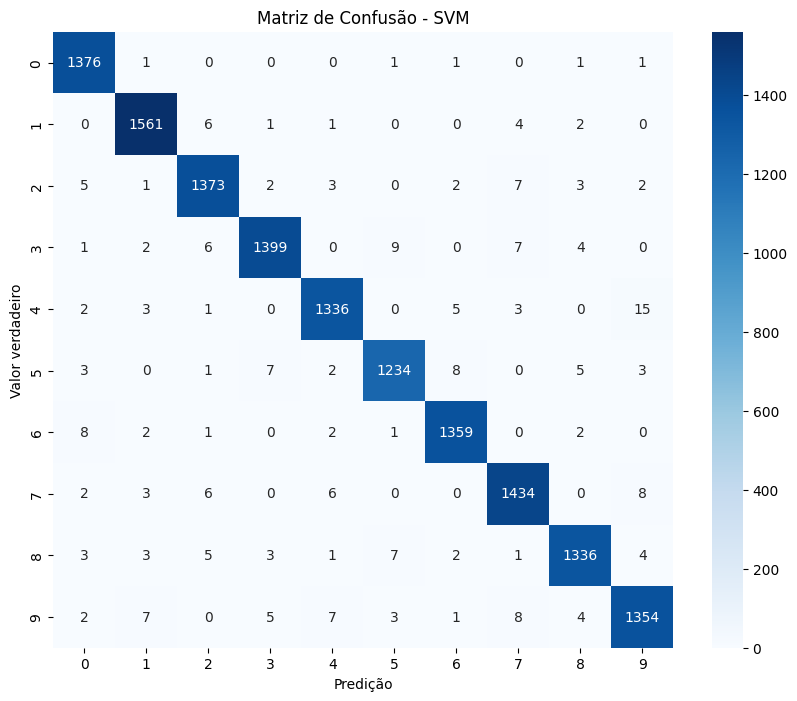

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# gerar o grafico 

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predição")
plt.ylabel("Valor verdadeiro")
plt.title("Matriz de Confusão - SVM")

plt.show()

# Heatmap do Random Forest

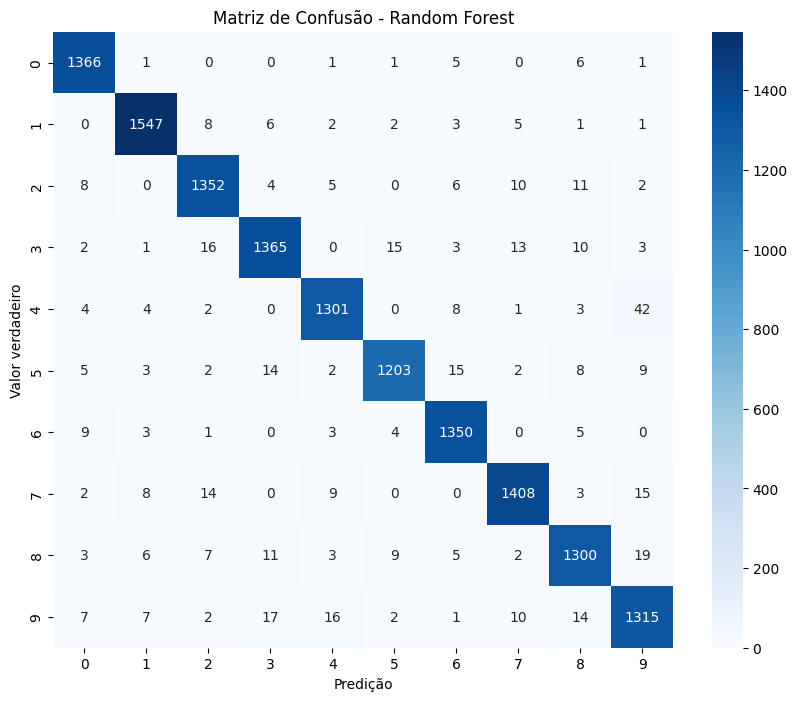

In [ ]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)


# gerar o grafico

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predição")
plt.ylabel("Valor verdadeiro")
plt.title("Matriz de Confusão - Random Forest")

plt.show()

# Heatmap da MLP

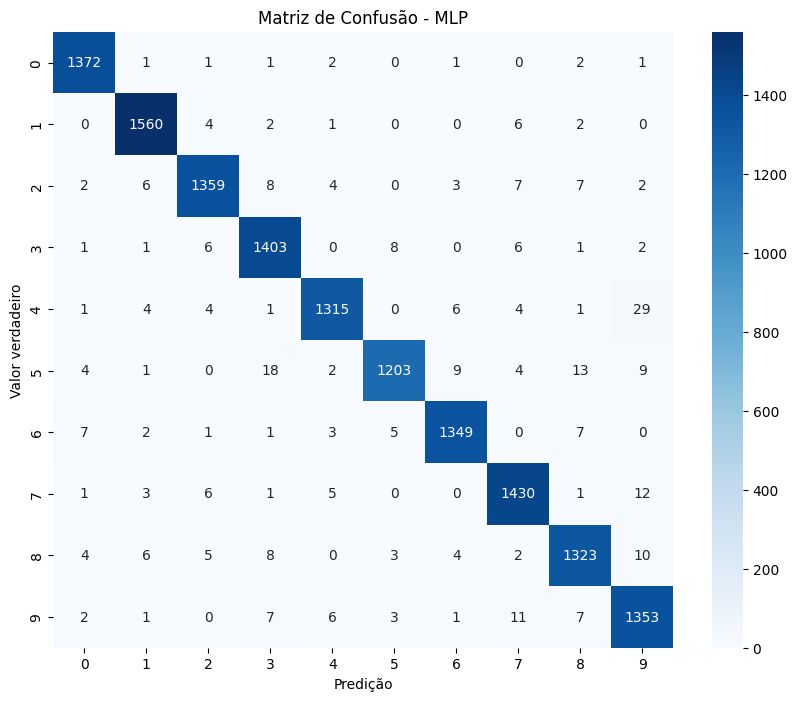

In [60]:
cm_mlp = confusion_matrix(
    y_test,
    y_pred_mlp
)

# gerar o grafico

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_mlp,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predição")
plt.ylabel("Valor verdadeiro")
plt.title("Matriz de Confusão - MLP")

plt.show()

# Descobrir automaticamente as maiores confusões

podemos fazer uma análise mais interessante do que simplesmente olhar para o gráfico.

In [68]:
import numpy as np

def maiores_confusoes(cm, quantidade=3):

    matriz = cm.copy()

    # Remove a diagonal principal
    for i in range(matriz.shape[0]):
        matriz[i, i] = 0

    indices = np.argsort(matriz.ravel())[::-1]

    resultados = []

    for indice in indices:

        linha, coluna = np.unravel_index(
            indice,
            matriz.shape
        )

        erros = int(matriz[linha, coluna])

        if erros > 0:
            resultados.append(
                f"{int(linha)} → {int(coluna)}: {erros} erros"
            )

        if len(resultados) == quantidade:
            break

    return resultados

In [69]:
print("Maiores confusões - SVM")
print(maiores_confusoes(cm_svm))

Maiores confusões - SVM
['4 → 9: 15 erros', '3 → 5: 9 erros', '9 → 7: 8 erros']


# Comparar o custo computacional

In [70]:
resultados["Tempo_Treinamento_s"] = [
    tempo_svm,
    tempo_rf,
    tempo_mlp
]

resultados

,Accuracy,Precision_Weighted,Recall_Weighted,F1_Weighted,Tempo_Treinamento_s
SVM,0.983000,0.983004,0.983000,0.982991,173.542500
Random Forest,0.964786,0.964824,0.964786,0.964768,16.074268
MLP,0.976214,0.976301,0.976214,0.976203,47.481259


# Identificar o melhor modelo automaticamente

In [71]:
# F1

melhor_modelo = resultados["F1_Weighted"].idxmax()

print("Melhor modelo:", melhor_modelo)

# Acurácia

melhor_accuracy = resultados["Accuracy"].idxmax()

print("Maior Accuracy:", melhor_accuracy)


# o modelo escolhido como melhor deve ser analisado considerando o conjunto das métricas, e não apenas uma delas.

Melhor modelo: SVM
Maior Accuracy: SVM


In [72]:
print("=== CONCLUSÃO TÉCNICA ===")

print(f"Modelo com maior Accuracy: {melhor_accuracy}")
print(f"Modelo com maior F1-Score: {melhor_modelo}")

=== CONCLUSÃO TÉCNICA ===
Modelo com maior Accuracy: SVM
Modelo com maior F1-Score: SVM


In [80]:
print("\nMaiores confusões por modelo:")
print("(Qual foi o par de classes que mais se confundiu?)")

print("\nSVM:")
print(maiores_confusoes(cm_svm)[:3])

print("\nRandom Forest:")
print(maiores_confusoes(cm_rf)[:3])

print("\nMLP:")
print(maiores_confusoes(cm_mlp)[:3])


Maiores confusões por modelo:
(Qual foi o par de classes que mais se confundiu?)

SVM:
['4 → 9: 15 erros', '3 → 5: 9 erros', '9 → 7: 8 erros']

Random Forest:
['4 → 9: 42 erros', '8 → 9: 19 erros', '9 → 3: 17 erros']

MLP:
['4 → 9: 29 erros', '5 → 3: 18 erros', '5 → 8: 13 erros']


# Calcular a taxa de erro de cada dígito

In [74]:
def taxa_erro_por_classe(cm):

    taxas = []

    for classe in range(cm.shape[0]):

        total = cm[classe].sum()
        corretos = cm[classe, classe]

        taxa_erro = (total - corretos) / total

        taxas.append(taxa_erro)

    return taxas

In [89]:
print("\nQual classe apresentou maior proporção de classificações incorretas?\n")


taxas_svm = taxa_erro_por_classe(cm_svm)

for classe, taxa in enumerate(taxas_svm):

    print(
        f"Dígito {classe}: "
        f"{taxa:.2%} de erro"
    )


Qual classe apresentou maior proporção de classificações incorretas?

Dígito 0: 0.36% de erro
Dígito 1: 0.89% de erro
Dígito 2: 1.79% de erro
Dígito 3: 2.03% de erro
Dígito 4: 2.12% de erro
Dígito 5: 2.30% de erro
Dígito 6: 1.16% de erro
Dígito 7: 1.71% de erro
Dígito 8: 2.12% de erro
Dígito 9: 2.66% de erro


# Descobrir automaticamente o dígito com maior taxa de erro

In [91]:
classe_maior_erro_svm = np.argmax(taxas_svm)

print("\nQual digito apresentou maior taxa de erro?\n")

print(
    f"Maior taxa de erro do SVM: "
    f"dígito {classe_maior_erro_svm} "
    f"({taxas_svm[classe_maior_erro_svm]:.2%})"
)



Qual digito apresentou maior taxa de erro?

Maior taxa de erro do SVM: dígito 9 (2.66%)


In [77]:
taxas_rf = taxa_erro_por_classe(cm_rf)
taxas_mlp = taxa_erro_por_classe(cm_mlp)

classe_maior_erro_rf = np.argmax(taxas_rf)
classe_maior_erro_mlp = np.argmax(taxas_mlp)

print(
    f"Random Forest: dígito {classe_maior_erro_rf} "
    f"({taxas_rf[classe_maior_erro_rf]:.2%})"
)

print(
    f"MLP: dígito {classe_maior_erro_mlp} "
    f"({taxas_mlp[classe_maior_erro_mlp]:.2%})"
)

Random Forest: dígito 9 (5.46%)
MLP: dígito 5 (4.75%)


# FAZER AJUSTE NESTA RESPOSTA - - -  Conclusão técnica:  
A análise das matrizes de confusão demonstrou que a principal confusão observada entre os modelos ocorreu entre os dígitos 4 e 9, com o padrão 4 → 9 aparecendo como uma das principais fontes de erro.  
 O modelo X apresentou a maior performance global, considerando Accuracy e F1-Score ponderado. Em relação ao custo computacional, o modelo Y apresentou menor tempo de treinamento, enquanto o modelo X apresentou maior desempenho, indicando um trade-off entre custo computacional e capacidade preditiva.

In [92]:
resultados

maiores_confusoes(cm_svm)
maiores_confusoes(cm_rf)
maiores_confusoes(cm_mlp)

taxas_svm = taxa_erro_por_classe(cm_svm)
taxas_rf = taxa_erro_por_classe(cm_rf)
taxas_mlp = taxa_erro_por_classe(cm_mlp)